In [1]:
import string
import textwrap

import faceted
import numpy as np
import pandas as pd
import wandb
import xarray as xr

import plotting
import utils

In [2]:
def load_metrics_from_wandb(run, keys):
    history = pd.DataFrame(run.scan_history(keys=keys))
    ds = xr.Dataset.from_dataframe(history)
    ds = ds.rename({"index": "time"})
    ds["time"] = xr.date_range("2031-01-01T12", periods=ds.sizes["time"], freq="6h")
    ds = ds.assign_coords(time=ds.time)
    return ds.rename({s: s.rsplit('/', 1)[-1] for s in ds.data_vars})


def load_panel_a_data():
    run_ids = {
        "1xCO2": utils.wandb_id_from_name("2026-02-20-data-only-evaluator-1xCO2-ic1"),
        "2xCO2": utils.wandb_id_from_name("2026-02-20-data-only-evaluator-2xCO2-ic1"),
        "4xCO2": utils.wandb_id_from_name("2026-02-20-data-only-evaluator-4xCO2-ic1"),
    }

    api = wandb.Api()

    runs = {}
    for name, id in run_ids.items():
        runs[name] = api.run(id)

    variable_names = ["implied_tendency_of_total_energy_ace2_path_due_to_advection"]
    metric_names = [f"inference/mean/weighted_mean_gen/{var}" for var in variable_names]

    datasets = {}
    for climate, run in runs.items():
        datasets[climate] = load_metrics_from_wandb(run, metric_names)
    return xr.concat(datasets.values(), dim=pd.Index(datasets.keys(), name="climate"))


def load_panel_b_data():
    run_ids = {
        "SHiELD-SOM": utils.wandb_id_from_name("2026-02-20-data-only-evaluator-3xCO2-ic1"),
        "full-rs0": utils.wandb_id_from_name("2026-09-09-full-rs0-3xCO2-ic1"),
        "full-rs1": utils.wandb_id_from_name("2026-09-09-full-rs1-3xCO2-ic1"),
        "full-energy-conserving-rs0": utils.wandb_id_from_name("2026-09-09-full-energy-conserving-rs0-3xCO2-ic1"),
        "full-energy-conserving-rs1": utils.wandb_id_from_name("2026-09-09-full-energy-conserving-rs1-3xCO2-ic1"),
    }

    api = wandb.Api()

    runs = {}
    for name, id in run_ids.items():
        runs[name] = api.run(id)

    variable_names = ["implied_tendency_of_total_energy_ace2_path_due_to_advection"]
    metric_names = [f"inference/mean/weighted_mean_gen/{var}" for var in variable_names]

    datasets = {}
    for case, run in runs.items():
        datasets[case] = load_metrics_from_wandb(run, metric_names)
    return xr.concat(datasets.values(), dim=pd.Index(datasets.keys(), name="case"))

In [3]:
LABELS = {
    "1xCO2": "1xCO$_2$",
    "2xCO2": "2xCO$_2$",
    "4xCO2": "4xCO$_2$",
}
COLORS = {
    "full-rs1": "C5",
    "SHiELD-SOM": "k",
    "full-energy-conserving-rs0": "C4",
}
CASE_LABELS = {
    "SHiELD-SOM": "SHiELD",
    "full-rs1": "ACE2S-SHiELD+$_{\\text{no-EC}}$",
    "full-energy-conserving-rs0": "ACE2S-SHiELD+",
}
ALTERNATE_SEEDS = {
    "full-rs1": "full-rs0",
    "full-energy-conserving-rs0": "full-energy-conserving-rs1"
}

In [4]:
plotting.configure_style()

In [5]:
ds_a = load_panel_a_data()
ds_b = load_panel_b_data()

print(ds_a.isnull().to_array().any())
print(ds_b.isnull().to_array().any())

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/spencerc/.netrc.


<xarray.DataArray ()> Size: 1B
array(False)
<xarray.DataArray ()> Size: 1B
array(False)


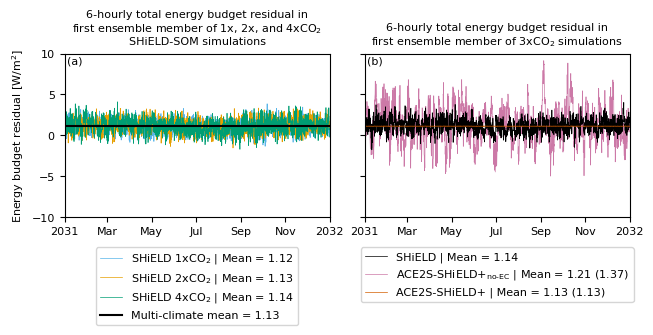

In [8]:
fig, (ax1, ax2) = faceted.faceted(1, 2, width=6.5, aspect=0.618, internal_pad=0.35, bottom_pad=1.15, top_pad=0.5, left_pad=0.6)

for climate, label in LABELS.items():
    time_mean = ds_a.implied_tendency_of_total_energy_ace2_path_due_to_advection.sel(climate=climate).mean("time").item()
    label = f"SHiELD {label} | Mean = {time_mean:0.2f}"
    ds_a.implied_tendency_of_total_energy_ace2_path_due_to_advection.sel(time="2031", climate=climate).plot(ax=ax1, lw=0.5, label=label)

ax1.axhline(1.13, color="k", label="Multi-climate mean = 1.13")
ax1.set_xlabel("")
ax1.set_ylabel(textwrap.fill("Energy budget residual [W/m$^2$]", width=35))
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15))
ax1.set_title(textwrap.fill("6-hourly total energy budget residual in first ensemble member of 1x, 2x, and 4xCO$_2$ SHiELD-SOM simulations", width=45))

full_case_labels = {}
for case, color in COLORS.items():
    time_mean = ds_b.implied_tendency_of_total_energy_ace2_path_due_to_advection.sel(case=case).mean("time").item()
    if case in ALTERNATE_SEEDS:
        alternate_seed = ALTERNATE_SEEDS[case]
        alternate_time_mean = ds_b.implied_tendency_of_total_energy_ace2_path_due_to_advection.sel(case=alternate_seed).mean("time").item()
        label = f"{CASE_LABELS[case]} | Mean = {time_mean:0.2f} ({alternate_time_mean:0.2f})"
    else:
        label = f"{CASE_LABELS[case]} | Mean = {time_mean:0.2f}"
    full_case_labels[case] = label
    ds_b.implied_tendency_of_total_energy_ace2_path_due_to_advection.sel(time="2031", case=case).plot(ax=ax2, lw=0.5, color=color, label=label)

ax2.set_title(textwrap.fill("6-hourly total energy budget residual in first ensemble member of 3xCO$_2$ simulations", width=45))
ax2.set_ylabel("")

handles, labels = ax2.get_legend_handles_labels()
handle_order = ["SHiELD-SOM", "full-rs1", "full-energy-conserving-rs0"]
label_to_handle = dict(zip(labels, handles))
ordered_handles = [label_to_handle[full_case_labels[case]] for case in handle_order]
ordered_labels = [full_case_labels[case] for case in handle_order]
ax2.legend(ordered_handles, ordered_labels, loc="upper center", bbox_to_anchor=(0.5, -0.15))

for ax in (ax1, ax2):
    ax.set_ylim(-10, 10)
    ax.set_xlabel("")
    ax.set_xlim(np.datetime64("2031"), np.datetime64("2032"))

for ax, label in zip((ax1, ax2), string.ascii_lowercase):
    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(2, -2),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
    )

fig.patch.set_alpha(0.0)
fig.savefig("figure-A01.png", dpi=300)
fig.savefig("figure-A01.pdf")
